In [9]:
"""
==========================

This script performs an end‑to‑end machine‑learning workflow on the
Pima‑Indians diabetes dataset.  The following steps are covered:

1. **Data loading and inspection** – read the CSV file and display
   basic statistics.
2. **Data cleaning** – treat zeros in selected physiological
   variables as missing values, create missingness indicators and
   impute the missing values using medians.
3. **Feature engineering** – derive a glucose–insulin ratio and an
   age–BMI interaction term to capture non‑linear relationships.
4. **Train/test split** – create a stratified 80/20 split of the
   dataset.
5. **Model training** – fit a decision tree (with hyper‑parameter
   optimisation), random forest (with hyper‑parameter optimisation) and
   K‑nearest neighbours classifier (tuning the number of neighbours).
6. **Evaluation** – compute accuracy, precision and recall for
   each model and report the best hyper‑parameters.

"""

'\n==========================\n\nThis script performs an end‑to‑end machine‑learning workflow on the\nPima‑Indians diabetes dataset.  The following steps are covered:\n\n1. **Data loading and inspection** – read the CSV file and display\n   basic statistics.\n2. **Data cleaning** – treat zeros in selected physiological\n   variables as missing values, create missingness indicators and\n   impute the missing values using medians.\n3. **Feature engineering** – derive a glucose–insulin ratio and an\n   age–BMI interaction term to capture non‑linear relationships.\n4. **Train/test split** – create a stratified 80/20 split of the\n   dataset.\n5. **Model training** – fit a decision tree (with hyper‑parameter\n   optimisation), random forest (with hyper‑parameter optimisation) and\n   K‑nearest neighbours classifier (tuning the number of neighbours).\n6. **Evaluation** – compute accuracy, precision and recall for\n   each model and report the best hyper‑parameters.\n\n'

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
### Load dataset


df= pd.read_csv("/content/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [22]:
### EDA
print("Dataset head:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())

Dataset head:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  Glucose_Missing  \
0                     0.627   50        1                0   
1                     0.351   31        0                0   
2                     0.672   32        1                0   
3                     0.167   21        0                0   
4                     2.288   33        1                0   

   BloodPressure_Missing  SkinThickness_Missing  Insulin_Missing  BMI_Missing  \
0                      0                      0                1            0   
1                 

In [23]:
display(df.dtypes)
display(df.columns)

,0
Pregnancies,int64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64
Glucose_Missing,int64


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_Missing',
       'BloodPressure_Missing', 'SkinThickness_Missing', 'Insulin_Missing',
       'BMI_Missing', 'GlucoseInsulinRatio', 'AgeBMIInteraction'],
      dtype='object')

In [15]:
### Checking for missing values
display(df.isnull().sum())

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [25]:
""" For better understanding I decided to check the exact numbers of zeros present"""

# Checking how many zeros there are in each column (potential missing values)
zero_counts = (df == 0).sum()
print("\nCounts of zeros per column:")
print(zero_counts)



Counts of zeros per column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
Glucose_Missing             763
BloodPressure_Missing       733
SkinThickness_Missing       541
Insulin_Missing             394
BMI_Missing                 757
GlucoseInsulinRatio           0
AgeBMIInteraction             0
dtype: int64


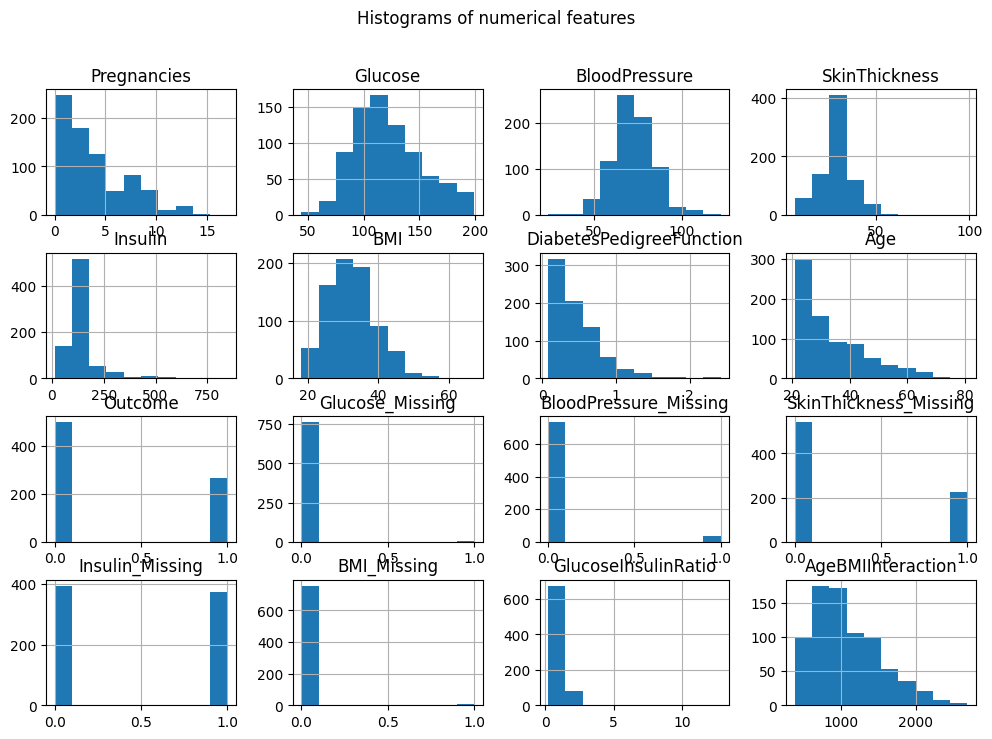

In [30]:
# Histograms of all features
df.hist(figsize=(12, 8))
plt.suptitle("Histograms of numerical features")
plt.show()


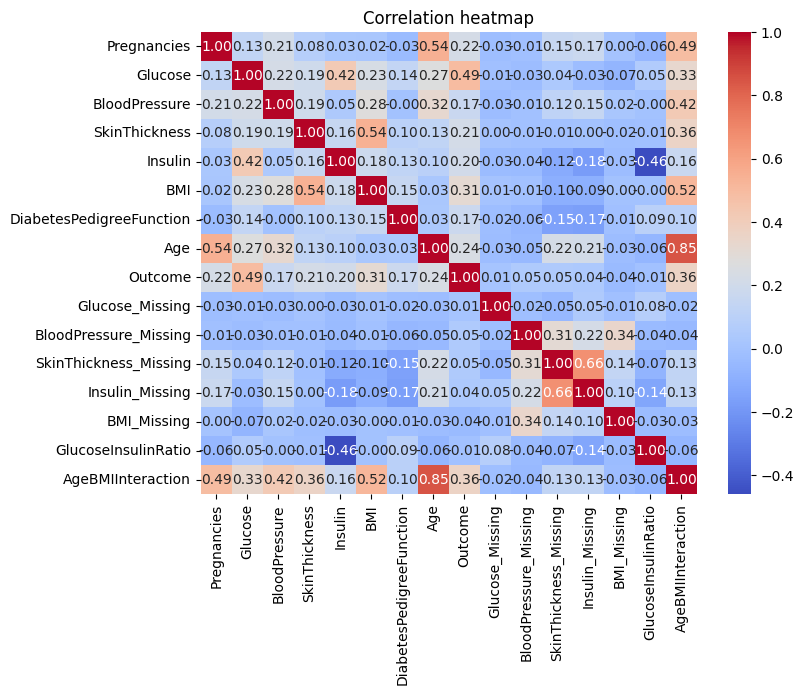

In [35]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap")
plt.show()


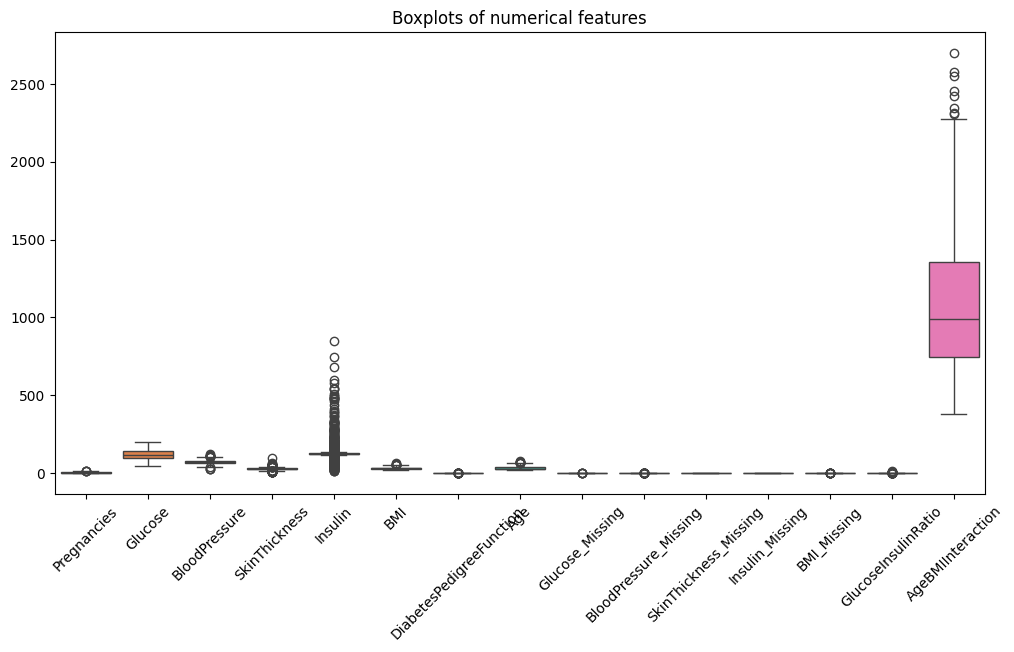

In [36]:
# Boxplots to identify outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['Outcome']))
plt.xticks(rotation=45)
plt.title("Boxplots of numerical features")
plt.show()

In [37]:
#  As in this context zeros are as missing values for certain columns
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_zero_cols:
    df[f'{col}_Missing'] = (df[col] == 0).astype(int)
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

In [38]:
#  Impute missing values with the median
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].median())


In [39]:
#  Feature engineering: ratios and interactions
df['GlucoseInsulinRatio'] = df['Glucose'] / (df['Insulin'] + 1e-6)
df['AgeBMIInteraction'] = df['Age'] * df['BMI']

#  Feature matrix and target vector
X = df.drop(columns=['Outcome'])
y = df['Outcome']


In [41]:
#  Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:

# 8. Decision Tree with grid search
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)
dt_metrics = {
    'accuracy': accuracy_score(y_test, dt_pred),
    'precision': precision_score(y_test, dt_pred),
    'recall': recall_score(y_test, dt_pred),
}

In [43]:
# 9. Random Forest with grid search
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_metrics = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
}
rf_importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)


In [44]:
# 10. K-Nearest Neighbours (KNN) with scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_accuracies = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, knn_pred)
    knn_accuracies.append(acc)
best_k = int(np.argmax(knn_accuracies)) + 1
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
knn_pred = best_knn.predict(X_test_scaled)
knn_metrics = {
    'accuracy': accuracy_score(y_test, knn_pred),
    'precision': precision_score(y_test, knn_pred),
    'recall': recall_score(y_test, knn_pred),
}


In [45]:


# 11. Display results
print("Decision Tree Performance:")
print(f"  Best params: {dt_grid.best_params_}")
print(f"  Accuracy:  {dt_metrics['accuracy']:.3f}")
print(f"  Precision: {dt_metrics['precision']:.3f}")
print(f"  Recall:    {dt_metrics['recall']:.3f}\n")

print("Random Forest Performance:")
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Accuracy:  {rf_metrics['accuracy']:.3f}")
print(f"  Precision: {rf_metrics['precision']:.3f}")
print(f"  Recall:    {rf_metrics['recall']:.3f}\n")
print("  Top feature importances (top 5):")
print(rf_importances.head(5), "\n")

print("K-Nearest Neighbours Performance:")
print(f"  Best k: {best_k}")
print(f"  Accuracy:  {knn_metrics['accuracy']:.3f}")
print(f"  Precision: {knn_metrics['precision']:.3f}")
print(f"  Recall:    {knn_metrics['recall']:.3f}")

Decision Tree Performance:
  Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
  Accuracy:  0.695
  Precision: 0.667
  Recall:    0.259

Random Forest Performance:
  Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
  Accuracy:  0.734
  Precision: 0.651
  Recall:    0.519

  Top feature importances (top 5):
Glucose              0.289259
AgeBMIInteraction    0.156228
BMI                  0.120061
Insulin              0.086921
Age                  0.080620
dtype: float64 

K-Nearest Neighbours Performance:
  Best k: 8
  Accuracy:  0.747
  Precision: 0.692
  Recall:    0.500


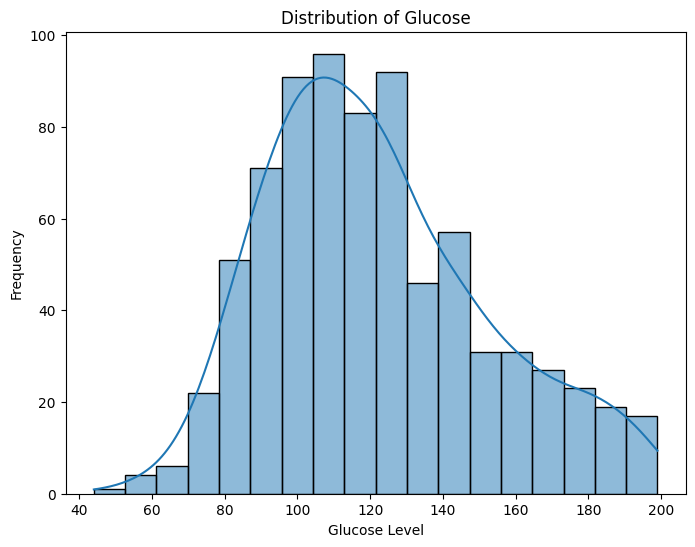

In [48]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Glucose'], kde=True)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.show()

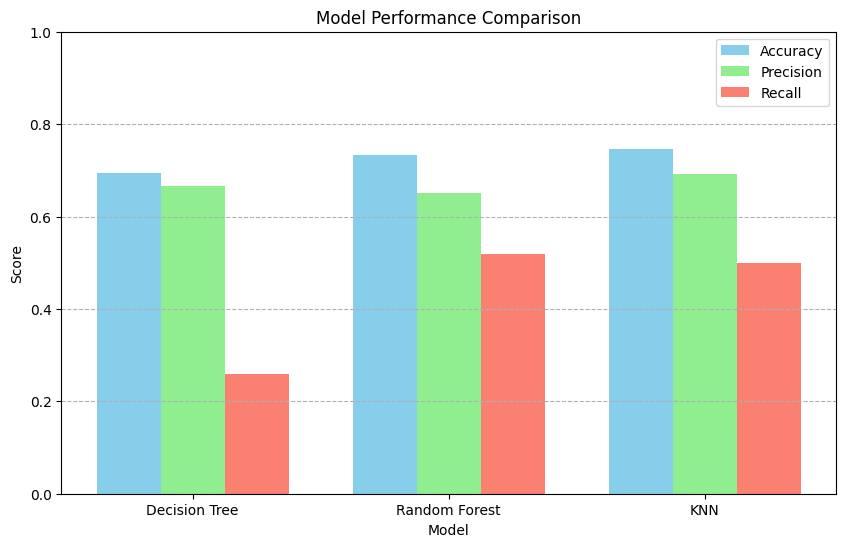

In [46]:
metrics_data = {
    'Model': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [dt_metrics['accuracy'], rf_metrics['accuracy'], knn_metrics['accuracy']],
    'Precision': [dt_metrics['precision'], rf_metrics['precision'], knn_metrics['precision']],
    'Recall': [dt_metrics['recall'], rf_metrics['recall'], knn_metrics['recall']]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(metrics_df['Model']))

plt.bar(index, metrics_df['Accuracy'], bar_width, label='Accuracy', color='skyblue')
plt.bar(index + bar_width, metrics_df['Precision'], bar_width, label='Precision', color='lightgreen')
plt.bar(index + 2 * bar_width, metrics_df['Recall'], bar_width, label='Recall', color='salmon')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(index + bar_width, metrics_df['Model'])
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--')
plt.show()

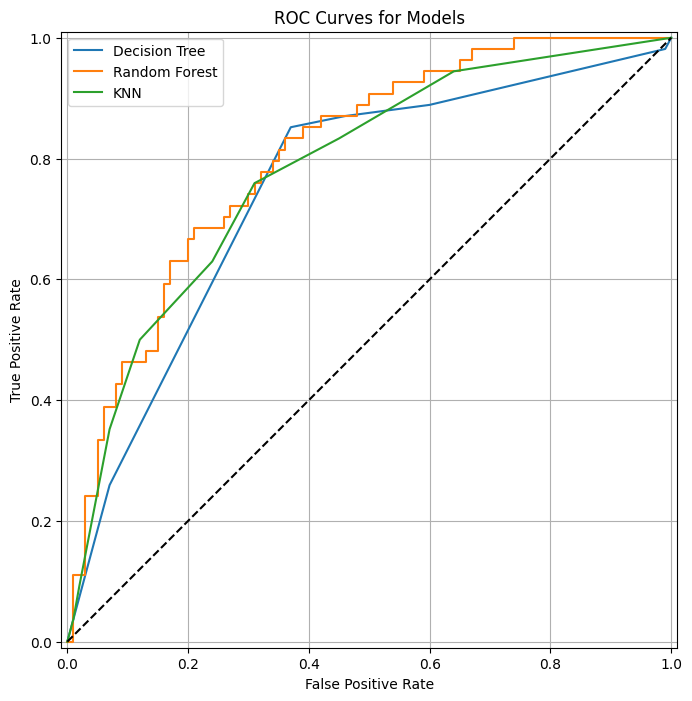

In [52]:
from sklearn.metrics import roc_curve, RocCurveDisplay

# Get predicted probabilities for the test set
dt_proba = dt_best.predict_proba(X_test)[:, 1]
rf_proba = rf_best.predict_proba(X_test)[:, 1]
knn_proba = best_knn.predict_proba(X_test_scaled)[:, 1] # Use scaled data for KNN

# Calculate ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)

# Plot ROC curves
plt.figure(figsize=(10, 8))
RocCurveDisplay(fpr=fpr_dt, tpr=tpr_dt).plot(label='Decision Tree', ax=plt.gca())
RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf).plot(label='Random Forest', ax=plt.gca())
RocCurveDisplay(fpr=fpr_knn, tpr=tpr_knn).plot(label='KNN', ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--') # Plot random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend()
plt.grid(True)
plt.show()

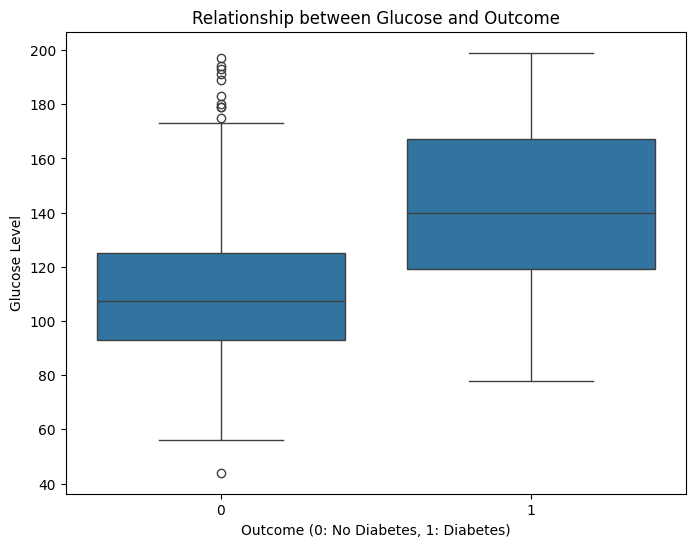

In [53]:
## For Visuals
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Relationship between Glucose and Outcome')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Glucose Level')
plt.show()

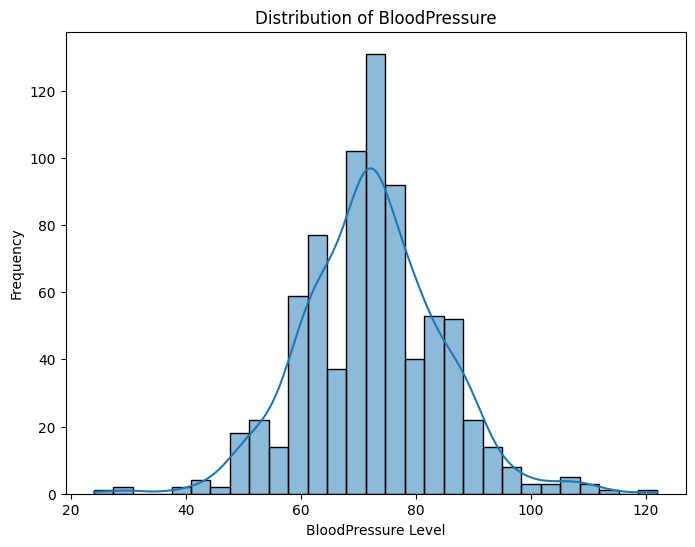

In [58]:
plt.figure(figsize=(8, 6))
sns.histplot(df['BloodPressure'], kde=True)
plt.title('Distribution of BloodPressure')
plt.xlabel('BloodPressure Level')
plt.ylabel('Frequency')
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

# Calculate AUC scores
auc_dt = roc_auc_score(y_test, dt_proba)
auc_rf = roc_auc_score(y_test, rf_proba)
auc_knn = roc_auc_score(y_test, knn_proba)

print(f"AUC for Decision Tree: {auc_dt:.3f}")
print(f"AUC for Random Forest: {auc_rf:.3f}")
print(f"AUC for KNN: {auc_knn:.3f}")

AUC for Decision Tree: 0.751
AUC for Random Forest: 0.805
AUC for KNN: 0.780


/tmp/ipython-input-3695742350.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=auc_df, palette='viridis')


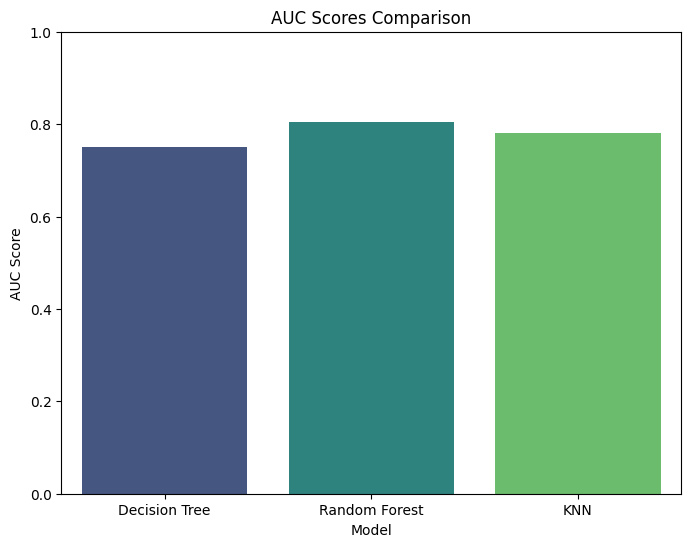

In [57]:
auc_data = {
    'Model': ['Decision Tree', 'Random Forest', 'KNN'],
    'AUC': [auc_dt, auc_rf, auc_knn]
}

auc_df = pd.DataFrame(auc_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='AUC', data=auc_df, palette='viridis')
plt.title('AUC Scores Comparison')
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.ylim(0, 1)
plt.show()